# 1D slice of Fisher-Rao energy at $t=0.1$ — basic vs. Bayesian v1 vs. v2

Same layout as `03_fisher_rao_geometry.ipynb`'s "1D slice" figure (same 12-atom sine-curve toy
manifold, same seed, same $t=0.1$), but now overlaying the energy curve for several regularization
strengths of each method:

- **basic** (`basic_fr.fisher_rao_energy`): plain softmax posterior over the retrieved neighbors,
  no prior — the reference curve, sharp valleys at each atom and sharp peaks at Laguerre-cell
  boundaries.
- **bayesian v1** (`bayesian_fr.fisher_rao_energy_bb`, bootstrap): Dirichlet(`dirichlet_alpha`)
  prior over atom weights, Monte-Carlo averaged over `B` draws. Swept over `dirichlet_alpha`.
- **bayesian v2** (`bayesian_fr_v2.fisher_rao_energy_v2`, closed-form): Dirichlet(`alpha_0`) prior
  directly on the assignment, `kappa` pseudo-count evidence weight, closed-form posterior mean.
- **v2, distance-gated** (prototype, not in the library yet): same v2 formula, but `alpha_0` decays
  with distance to the nearest atom instead of being a constant. See markdown below for why.

Two versions below, same code path parameterized by `k` (the neighbor-set size):

- **`k=12`** (all atoms, i.e. no retrieval): smooth in $x$, matches `03`'s aesthetic. But it has a
  degenerate failure mode for v2: as `alpha_0 -> large`, `q_bar -> 1/12` (uniform) **independent of
  the query point**, so `I(q_bar)` collapses to the variance of the *whole atom cloud around its
  own mean* — a constant that does not depend on $x$ at all.
- **`k=5`**: retrieval-restricted like the real guidance pipeline (`02`/`04` use `k=3`; `k=5` here
  is a slightly looser middle ground), so the neighbor SET still changes with $x$ and the energy
  keeps *some* locality — at the cost of visible kinks where the retrieved set switches.

## Why v2's shape looked "basically like basic, just shifted" (and why unsupported regions could
## even score higher than supported ones)

`q_bar = (alpha_0 + kappa*q) / a0` is an exact convex combination `q_bar = lambda*q + (1-lambda)*u`
of the plug-in posterior `q` and the UNIFORM distribution `u` over the k retrieved atoms, with
`lambda = kappa / (k*alpha_0 + kappa)`. Because variance is quadratic (not linear) in the weights,
the law-of-total-variance gives an EXACT identity (verified against the library to float32
precision):

$$I(\bar q) = \lambda \cdot I(q) \;+\; (1-\lambda)\cdot C_{\text{floor}} \;+\; \lambda(1-\lambda)\cdot\|\mathbb{E}_q[g]-\mathbb{E}_u[g]\|^2/\sigma_t^2$$

where `C_floor = Var_u(g)` is the uniform-weighted variance of the k retrieved atoms' own
positions -- independent of the query point except through WHICH k atoms get retrieved. With a
constant `alpha_0`, `lambda` is a global constant too, so a large `alpha_0` doesn't reshape the
curve -- it drowns the shape in a big, roughly-flat, sometimes-larger-outside-support floor.

**Fix #1 (rows 1-3 below):** sweep `alpha_0` so that `lambda` itself moves smoothly from ~1 (pure
basic shape) down to ~0.5 (half shape, half floor) INSTEAD of jumping straight into the
floor-dominated regime. `alpha_0` is solved per-`k` from a target `lambda`:
`alpha_0 = kappa*(1-lambda)/(k*lambda)`.

**Fix #2 (row 4 below):** a constant `alpha_0` cannot separate "regularize near data" from "don't
invent structure far from data" -- both are controlled by the same number. Instead make the prior
strength itself decay with distance to the nearest atom:

$$\alpha_0(y) = \alpha_0^{\text{base}} \cdot \exp\!\Big(-\frac{d_{\min}(y)^2}{2\ell^2}\Big), \qquad d_{\min}(y) = \min_i \|y-\mu_i\|$$

and plug the resulting per-point `lambda(y) = kappa/(k*alpha_0(y)+kappa)` into the SAME exact
decomposition identity above (it holds pointwise, so a spatially-varying `lambda` is still exact,
not an approximation). Near data (`d_min << ell`) this reproduces constant-`alpha_0` valley-filling;
far from data (`d_min >> ell`) `alpha_0(y) -> 0`, so `lambda(y) -> 1` and the energy collapses back
to `I(q)` = `basic`, which already vanishes far from data on its own. `ell` is the only new knob:
the length scale beyond which the prior "turns off". Row 4 has no separate `basic`-vs-`gated`
benchmark curve overlaid -- just `basic` as reference plus the `ell` sweep, same as rows 2-3.

**Caveat:** the distance-gated variant is a prototype built here via the decomposition identity, not
a change to `src/guidance/bayesian_fr_v2.py` -- the real library function only takes a scalar
`alpha_0` and does not support this. Promoting it there is a separate decision.

In [1]:
import os, sys
import torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../../src"))
from guidance import basic_fr, bayesian_fr, bayesian_fr_v2

N_ATOMS  = 12
U_RANGE  = 3.2
SEED     = 7
BETA_MIN = 0.1
BETA_MAX = 20.0
T_SLICE  = 0.1
BETA_FLOOR = 0.05   # matches 04's config["beta_floor"]

torch.manual_seed(SEED)

def manifold_from_u(u):
    return torch.stack([u, 0.6 * torch.sin(2 * u)], dim=-1)

u_atoms = (torch.rand(N_ATOMS) * 2 - 1) * U_RANGE
X_atoms = manifold_from_u(u_atoms)   # [N, 2]

def alpha_bar(t):
    t = torch.as_tensor(t, dtype=torch.float32)
    return torch.exp(-(BETA_MIN * t + 0.5 * (BETA_MAX - BETA_MIN) * t ** 2))

def sigma2(t):
    return (1.0 - alpha_bar(t)).clamp(min=1e-6)

ab_s = alpha_bar(T_SLICE).item()
s2_s = sigma2(T_SLICE).item()
mu_s = X_atoms * ab_s ** 0.5          # [N, 2], scaled atom positions at t

x_vals  = torch.linspace(-4.0, 4.0, 1000)
z_slice = torch.stack([x_vals, torch.zeros_like(x_vals)], dim=-1)   # [M, 2]
beta_t  = torch.full((z_slice.shape[0],), s2_s)
x_np    = x_vals.numpy()

qual_colors = [plt.colormaps['tab20'](i / N_ATOMS) for i in range(N_ATOMS)]

V1_ALPHA_GRID   = [0.1, 0.25, 0.5, 1.0]
V1_B            = 256
V2_KAPPA        = 10.0
V2_LAMBDA_GRID  = [0.8, 0.9, 0.95]   # target lambda = kappa/(k*alpha_0+kappa); see markdown above

# row 4: distance-gated alpha_0(y) = ALPHA0_BASE * exp(-d_min(y)^2/(2*ell^2))
ALPHA0_BASE  = 0.05
KAPPA_GATED  = 10.0
ELL_GRID     = [0.05, 0.01, 0.075, 0.1, 0.5]

def alpha0_for_lambda(lam, k, kappa=V2_KAPPA):
    return kappa * (1 - lam) / (k * lam)

print(f'atoms={N_ATOMS}, t={T_SLICE}, alpha_bar={ab_s:.4f}, sigma2={s2_s:.4f}')

atoms=12, t=0.1, alpha_bar=0.8963, sigma2=0.1037


In [2]:
def knn_neighbors(k):
    """Top-k nearest atoms per query point, WITH global atom indices (unlike basic_fr.ann_query,
    which only returns positions) -- needed so Laguerre-cell shading colors stay tied to atom
    identity regardless of k. k=N_ATOMS reduces to 'all atoms', ordered by distance."""
    d2 = torch.cdist(z_slice, mu_s) ** 2
    _, idx = torch.topk(d2, k, largest=False, dim=1)   # [M, k]
    return mu_s[idx], idx

def shade_cells(ax, owner_global, curve):
    """Matches 03_fisher_rao_geometry.ipynb's 1D slice: fill_between(x, 0, curve), i.e. only the
    area UNDER the reference curve is tinted -- not the whole panel background up to ymax."""
    for i in range(N_ATOMS):
        mask = (owner_global == i)
        if mask.any():
            ax.fill_between(x_np, 0, curve, where=mask, color=qual_colors[i], alpha=0.35, zorder=0)

def draw_atoms(ax):
    for xi in X_atoms[:, 0].numpy():
        ax.axvline(xi, color='#aaaaff', lw=0.7, alpha=0.4, ls='--', zorder=1)
    ax.scatter(X_atoms[:, 0].numpy(), np.zeros(N_ATOMS), s=70, marker='*',
               color='white', edgecolors='#333', linewidths=0.6, zorder=6)

def run_config(k):
    neighbors, knn_idx = knn_neighbors(k)

    I_basic_t, q_basic, g_basic = basic_fr.fisher_rao_energy(z_slice, neighbors, beta_t)
    I_basic = I_basic_t.detach().numpy()
    owner_global = knn_idx.gather(1, q_basic.argmax(1, keepdim=True)).squeeze(1).numpy()

    v1_curves = {}
    for da in V1_ALPHA_GRID:
        I_v1, _, _ = bayesian_fr.fisher_rao_energy_bb(z_slice, neighbors, beta_t, B=V1_B, dirichlet_alpha=da,
                                                       beta_floor=BETA_FLOOR)
        v1_curves[da] = I_v1.detach().numpy()

    # alpha_0 solved per-k so the SAME lambda grid is comparable across k=12 and k=5
    v2_curves = {}
    for lam in V2_LAMBDA_GRID:
        a0 = alpha0_for_lambda(lam, k)
        I_v2, _, _ = bayesian_fr_v2.fisher_rao_energy_v2(z_slice, neighbors, beta_t, alpha_0=a0, kappa=V2_KAPPA,
                                                           beta_floor=BETA_FLOOR)
        v2_curves[lam] = (a0, I_v2.detach().numpy())

    # Raw ingredients of the exact decomposition I(q_bar) = lambda*I(q) + (1-lambda)*C_floor +
    # lambda*(1-lambda)*cross_raw (verified against the library to float32 precision) -- kept here,
    # UN-weighted by any particular lambda, so a per-point (distance-gated) lambda can be plugged in
    # afterwards without re-deriving anything.
    u_w = torch.full_like(q_basic, 1.0 / k)
    Eu_g = (u_w.unsqueeze(-1) * g_basic).sum(1)
    Eu_g2 = (u_w * (g_basic ** 2).sum(-1)).sum(1)
    C_floor = ((Eu_g2 - (Eu_g ** 2).sum(-1)) / beta_t ** 2).detach().numpy()
    Eq_g = (q_basic.unsqueeze(-1) * g_basic).sum(1)
    cross_raw = (((Eq_g - Eu_g) ** 2).sum(-1) / beta_t ** 2).detach().numpy()
    d_min = torch.cdist(z_slice, mu_s).min(1).values.numpy()   # distance to nearest atom (any of the N_ATOMS)

    # row 4: distance-gated v2, one curve per ell in ELL_GRID
    gated_curves = {}
    for ell in ELL_GRID:
        alpha0_eff = ALPHA0_BASE * np.exp(-d_min ** 2 / (2 * ell ** 2))
        a0 = k * alpha0_eff + KAPPA_GATED
        lam = KAPPA_GATED / a0
        I_qbar = lam * I_basic + (1 - lam) * C_floor + lam * (1 - lam) * cross_raw
        gated_curves[ell] = (a0 / (a0 + 1)) * I_qbar

    return dict(I_basic=I_basic, owner_global=owner_global, v1_curves=v1_curves, v2_curves=v2_curves,
                C_floor=C_floor, cross_raw=cross_raw, d_min=d_min, k=k, gated_curves=gated_curves)


def plot_comparison(k, results, save_name):
    I_basic, owner_global = results['I_basic'], results['owner_global']
    v1_curves, v2_curves, gated_curves = results['v1_curves'], results['v2_curves'], results['gated_curves']

    fig, axes = plt.subplots(4, 1, figsize=(14.5, 13), facecolor='#0e0e0e', sharex=True)

    ax = axes[0]; ax.set_facecolor('#111')
    ymax0 = I_basic.max() * 1.15
    shade_cells(ax, owner_global, I_basic)
    ax.plot(x_np, I_basic, color='white', lw=2.0, zorder=3, label='basic (no prior)')
    draw_atoms(ax)
    ax.set_ylim(0, ymax0)
    ax.set_title(f'basic  (plain softmax posterior, no regularization, k={k})', color='white', fontsize=11)

    ax = axes[1]; ax.set_facecolor('#111')
    ymax1 = max(I_basic.max(), max(c.max() for c in v1_curves.values())) * 1.15
    shade_cells(ax, owner_global, I_basic)
    ax.plot(x_np, I_basic, color='white', lw=1.2, ls=':', alpha=0.5, zorder=2, label='basic (ref)')
    cmap = plt.colormaps['viridis']
    for i, da in enumerate(V1_ALPHA_GRID):
        ax.plot(x_np, v1_curves[da], lw=2.0, zorder=3,
                color=cmap(i / max(1, len(V1_ALPHA_GRID) - 1)),
                label=fr'$\alpha_D={da:g}$')
    draw_atoms(ax)
    ax.set_ylim(0, ymax1)
    ax.set_title(fr'bayesian v1 (bootstrap, $B={V1_B}$, k={k}) — sweep $\alpha_D$ (Dirichlet concentration)',
                 color='white', fontsize=11)

    ax = axes[2]; ax.set_facecolor('#111')
    ymax2 = max(I_basic.max(), max(c.max() for _, c in v2_curves.values())) * 1.15
    shade_cells(ax, owner_global, I_basic)
    ax.plot(x_np, I_basic, color='white', lw=1.2, ls=':', alpha=0.5, zorder=2, label='basic (ref)')
    cmap = plt.colormaps['plasma']
    for i, lam in enumerate(V2_LAMBDA_GRID):
        a0, curve = v2_curves[lam]
        ax.plot(x_np, curve, lw=2.0, zorder=3,
                color=cmap(i / max(1, len(V2_LAMBDA_GRID) - 1)),
                label=fr'$\lambda={lam:g}$ ($\alpha_0={a0:.3g}$)')
    draw_atoms(ax)
    ax.set_ylim(0, ymax2)
    ax.set_title(fr'bayesian v2 (closed-form, $\kappa={V2_KAPPA:g}$, k={k}) — sweep $\lambda=\kappa/(k\alpha_0+\kappa)$',
                 color='white', fontsize=11)

    ax = axes[3]; ax.set_facecolor('#111')
    ymax3 = max(I_basic.max(), max(c.max() for c in gated_curves.values())) * 1.15
    shade_cells(ax, owner_global, I_basic)
    ax.plot(x_np, I_basic, color='white', lw=1.2, ls=':', alpha=0.5, zorder=2, label='basic (ref)')
    cmap = plt.colormaps['cool']
    for i, ell in enumerate(ELL_GRID):
        ax.plot(x_np, gated_curves[ell], lw=2.2, zorder=3,
                color=cmap(i / max(1, len(ELL_GRID) - 1)),
                label=fr'$\ell={ell:g}$')
    draw_atoms(ax)
    ax.set_ylim(0, ymax3)
    ax.set_title(fr'bayesian v2, distance-gated (prototype, $\alpha_0^{{base}}={ALPHA0_BASE:g}$, $\kappa={KAPPA_GATED:g}$, k={k}) — sweep $\ell$',
                 color='white', fontsize=11)

    for ax in axes:
        ax.set_xlim(-4, 4)
        ax.tick_params(colors='white')
        for spine in ax.spines.values():
            spine.set_edgecolor('white')
        ax.set_ylabel(r'$I(y)$ / $E[I(y)]$', color='white')
        ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.005, 1.0), borderaxespad=0,
                  facecolor='#222', edgecolor='white', labelcolor='white')
    axes[-1].set_xlabel('$x$  (horizontal slice at $y=0$)', color='white', fontsize=11)

    fig.suptitle(
        f'1D slice of Fisher-Rao energy at $t={T_SLICE}$, k={k}: basic vs. Bayesian v1 (bootstrap) vs. v2 (closed-form) vs. v2 (distance-gated)\n'
        r'v2 swept by $\lambda$ (fraction of energy from the true shape, $I(q)$); gated v2 swept by $\ell$ (length scale beyond which the prior turns off).  Note: y-scales differ per panel.',
        fontsize=11, color='white', y=1.0)

    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f'Saved -> {save_name}')
    plt.show()

## $k=12$ (all atoms, no retrieval)

Saved -> bayesian_1d_slice_comparison_k12.png


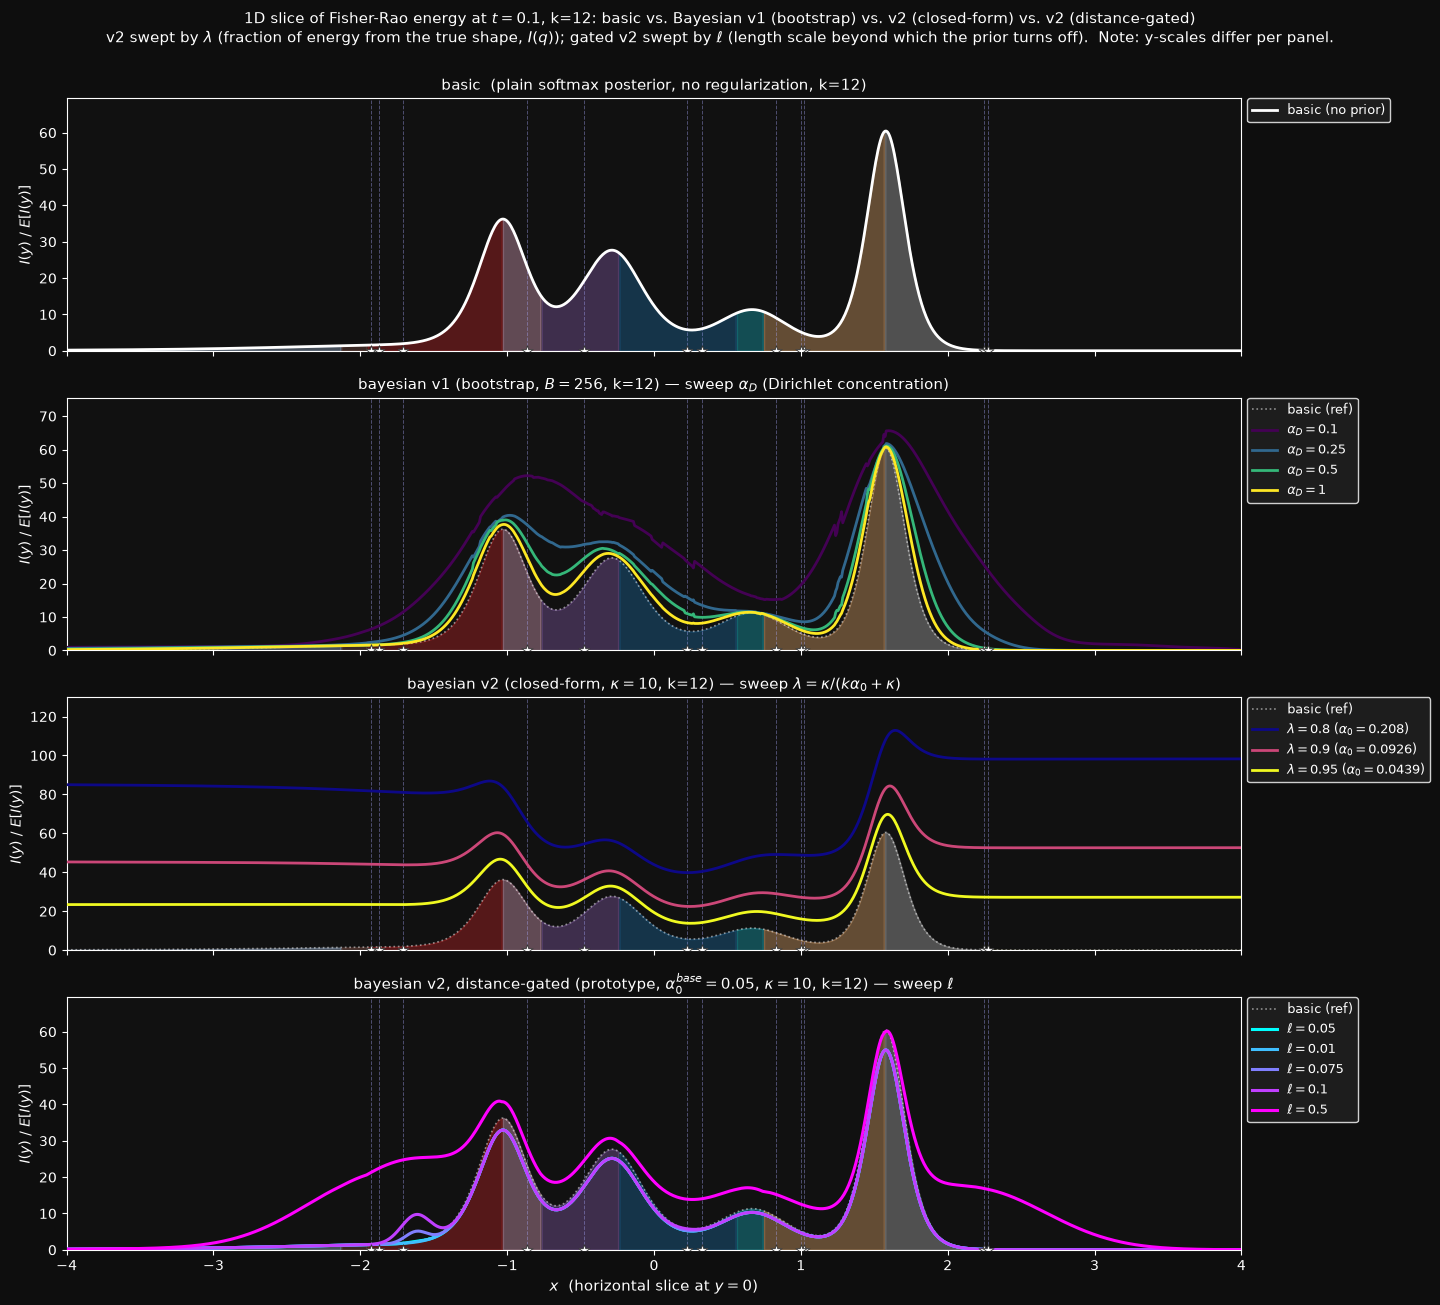

In [3]:
results_k12 = run_config(N_ATOMS)
plot_comparison(N_ATOMS, results_k12, 'bayesian_1d_slice_comparison_k12.png')

## $k=5$ (retrieval-restricted)

Same computation, same atoms, same $\lambda$/$\ell$ grids -- only the neighbor set size changes
(and therefore what `alpha_0` each `lambda` maps to, since
`alpha_0 = kappa*(1-lambda)/(k*lambda)` depends on `k`).

Saved -> bayesian_1d_slice_comparison_k5.png


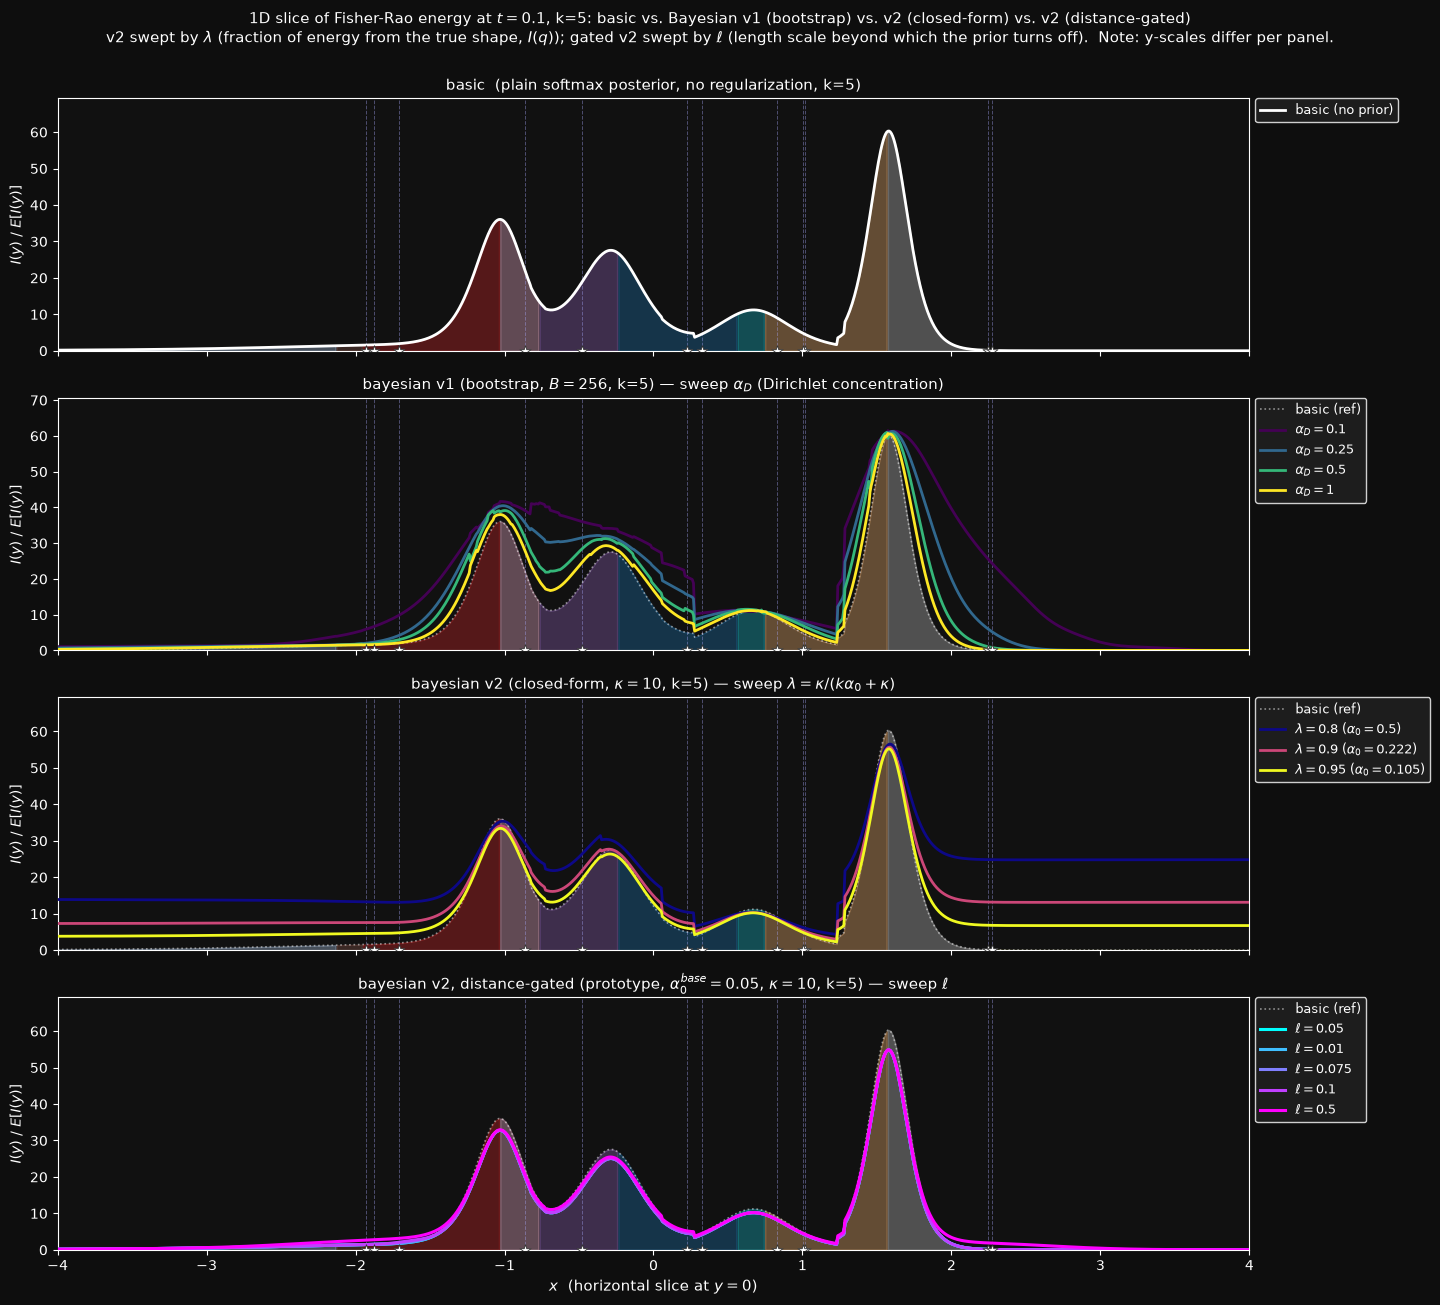

In [4]:
results_k5 = run_config(5)
plot_comparison(5, results_k5, 'bayesian_1d_slice_comparison_k5.png')